                               order_id  customer_id  product_id     category  \
0  b8ec9f86-5919-4b71-a5f7-945e7c0a3db0         2031         845        Books   
1  5ea92c47-c5b2-4bdd-8a50-d77efd77ec89         2350         995  Electronics   
2  5cc48ce0-2c6d-4448-af3f-96f8a910d45b         1818         997       Beauty   
3  74d5c0f4-53f0-4367-a5c5-baaa114c2d9f          472         385         Home   
4  7a630323-8ac8-406e-875a-4bcdead440ab         1075          31     Clothing   

    price  quantity                  order_date               shipping_date  \
0   45.95         4  2024-04-20 14:59:58.897063  2024-04-27 14:59:58.897063   
1  403.17         3  2024-04-20 14:59:58.897063  2024-04-22 14:59:58.897063   
2  317.45         2  2024-04-20 14:59:58.897063  2024-04-27 14:59:58.897063   
3   24.08         3  2024-04-20 14:59:58.897063  2024-04-24 14:59:58.897063   
4  494.90         1  2024-04-20 14:59:58.897063  2024-04-25 14:59:58.897063   

  delivery_status payment_method devic

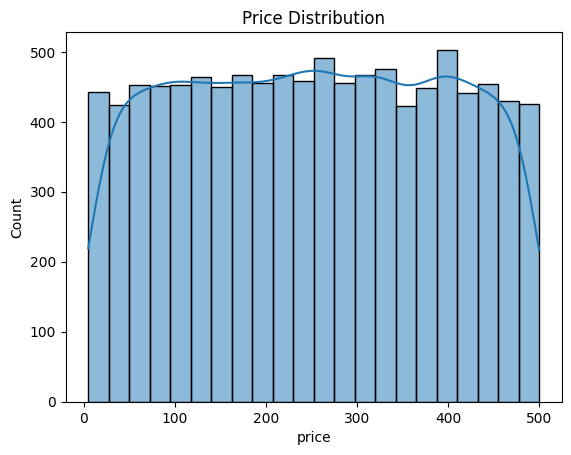

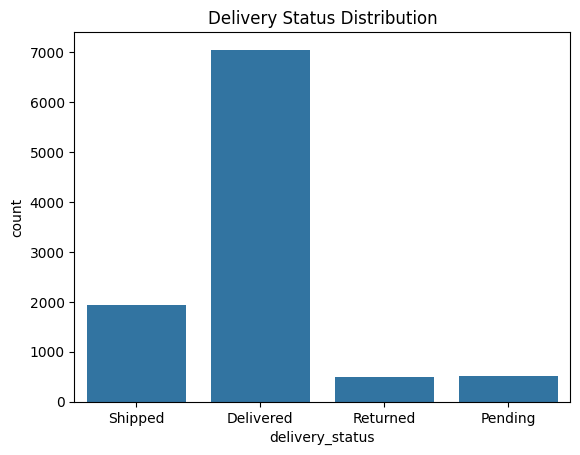

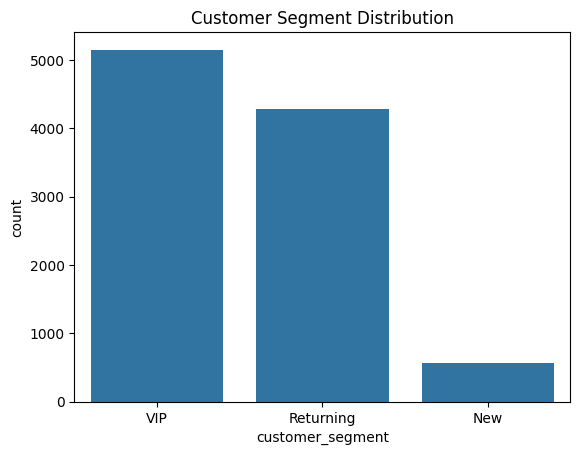

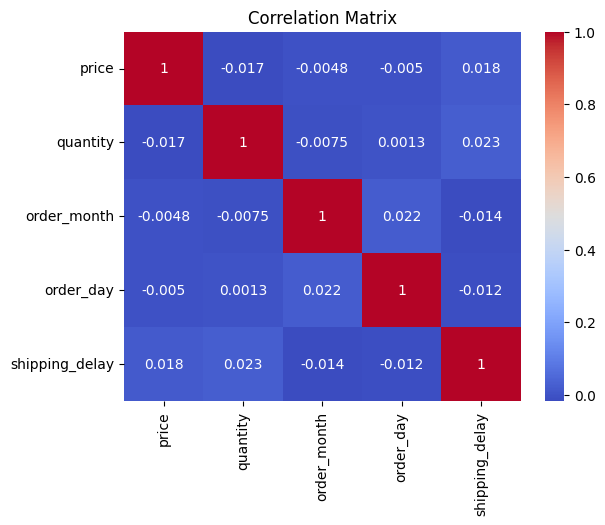

Preprocessor saved!


In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("../project/ecommerce_orders_raw_data.csv")

print(df.head())
print(df.info())

# ==============================
# 3. DATA CLEANING
# ==============================
df = df.drop(columns=[
    "order_id",
    "customer_id",
    "product_id",
    "shipping_address",
    "billing_address"
])

# ==============================
# 4. FEATURE ENGINEERING
# ==============================
df["order_date"] = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["shipping_delay"] = (df["shipping_date"] - df["order_date"]).dt.days

df = df.drop(columns=["order_date", "shipping_date"])

# ==============================
# 5. EDA
# ==============================
plt.figure()
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.countplot(x="delivery_status", data=df)
plt.title("Delivery Status Distribution")
plt.show()

plt.figure()
sns.countplot(x="customer_segment", data=df)
plt.title("Customer Segment Distribution")
plt.show()

plt.figure()
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 6. PREPROCESSING PIPELINE
# ==============================
X = df.drop(columns=["price", "delivery_status", "customer_segment"])

categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Save preprocessor
joblib.dump(preprocessor, "../artifacts/preprocessor.joblib")

print("Preprocessor saved!")